In [1]:
import os
import pickle
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
from tqdm import tqdm
import pandas as pd
import string
from collections import Counter

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT).to(device)
resnet.fc = nn.Identity()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 203MB/s]


In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
   transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [5]:
IMAGE_DIR = '/kaggle/input/datasets/adityajn105/flickr8k/Images'
features = {}

resnet.eval()

for img_name in tqdm(os.listdir(IMAGE_DIR)):
    img_path = os.path.join(IMAGE_DIR, img_name)

    image = Image.open(img_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
      feature_vector = resnet(image_tensor)
      features[img_name] = feature_vector.squeeze().cpu()

with open('/kaggle/working/features.pkl', "wb") as f:
  pickle.dump(features, f)
print(f"Successfully extracted and saved features for {len(features)} images!")

100%|██████████| 8091/8091 [02:47<00:00, 48.22it/s]


Successfully extracted and saved features for 8091 images!


In [6]:
def clean_caption(text):
  text = str(text)
  text = text.translate(str.maketrans('','', string.punctuation)).lower().strip()
  return f"<start> {text} <end>"

In [8]:
def load_and_group_captions(file_path):
    df = pd.read_csv(file_path)
    df['clean_caption'] = df['caption'].apply(clean_caption)

    # Group by image into a dictionary
    img_to_caps = df.groupby('image')['clean_caption'].apply(list).to_dict()

    return df, img_to_caps

In [9]:
def build_vocabulary(img_to_caps_dict, threshold=5):
  all_words = []

    # Grab every caption from the dictionary and extract the words
  for captions in img_to_caps_dict.values():
      for cap in captions:
          all_words.extend(cap.split())

  word_counts = Counter(all_words)
  frequent_words = [word for word, count in word_counts.items() if count >= threshold]
  w2id = {'<PAD>': 0, '<UNK>': 1}

  for i, word in enumerate(frequent_words):
    w2id[word] = i + 2

  id2w = {id: word for word, id in w2id.items()}
  return w2id, id2w, len(w2id)


In [10]:
caption_path = '/kaggle/input/datasets/adityajn105/flickr8k/captions.txt'

df_captions, image_to_captions = load_and_group_captions(caption_path)

# 2. Build the dictionaries
word_to_id, id_to_word, vocab_size = build_vocabulary(image_to_captions, threshold=5)

print("\n--- Phase 1 Complete ---")
print(f"Total unique images: {len(image_to_captions)}")
print(f"Final Vocabulary size: {vocab_size}")


--- Phase 1 Complete ---
Total unique images: 8091
Final Vocabulary size: 2995


In [11]:
first_img, first_caps = next(iter(image_to_captions.items()))

print(f"First Image: {first_img}")
print(f"First Caption in its list: {first_caps}")

First Image: 1000268201_693b08cb0e.jpg
First Caption in its list: ['<start> a child in a pink dress is climbing up a set of stairs in an entry way <end>', '<start> a girl going into a wooden building <end>', '<start> a little girl climbing into a wooden playhouse <end>', '<start> a little girl climbing the stairs to her playhouse <end>', '<start> a little girl in a pink dress going into a wooden cabin <end>']


In [18]:
from torch.utils.data import Dataset, DataLoader

class Flickr8k_Dataset(Dataset):
  def __init__(self, image_to_captions_dict, image_features_dict, word_to_id, max_length=40):
    self.image_to_captions_dict = image_to_captions_dict
    self.image_features_dict = image_features_dict
    self.word_to_id = word_to_id
    self.max_length = max_length

    self.samples = []

    for image_name, captions in image_to_captions_dict.items():
      if image_name in image_features_dict:
        for caption in captions:
          self.samples.append((image_name, caption))

  def __len__(self):
    return len(self.samples)

  def __getitem__(self, index):
    image_name, caption = self.samples[index]
    image_features = self.image_features_dict[image_name]

    tokens = caption.split()
    caption_ids = [self.word_to_id.get(word, 1) for word in tokens]

    # Padding
    if len(caption_ids) < self.max_length:
      caption_ids += [0] * (self.max_length - len(caption_ids))
    else:
      caption_ids = caption_ids[:self.max_length]

    return image_features, torch.tensor(caption_ids, dtype=torch.long)


In [19]:
import random
from torch.utils.data import DataLoader

# 1. Grab all unique image names and shuffle them
all_image_names = list(image_to_captions.keys())

random.seed(42)
random.shuffle(all_image_names)

# 2. Slice the list into Train, Val, and Test
train_names = all_image_names[:6000]
val_names = all_image_names[6000:7000]
test_names = all_image_names[7000:]

print(f"Splits - Train: {len(train_names)}, Val: {len(val_names)}, Test: {len(test_names)}")

# 3. Create separate dictionaries for each split
train_captions = {img: image_to_captions[img] for img in train_names}
val_captions = {img: image_to_captions[img] for img in val_names}
test_captions = {img: image_to_captions[img] for img in test_names}

# 4. CRITICAL: Build the vocabulary ONLY on the Train dictionary!
word_to_id, id_to_word, vocab_size = build_vocabulary(train_captions, threshold=5)

print(f"Strict Training Vocabulary Size: {vocab_size}")

# 5. Build three separate PyTorch Datasets using the SAME vocabulary
train_dataset = Flickr8k_Dataset(train_captions, features, word_to_id, max_length=40)
val_dataset = Flickr8k_Dataset(val_captions, features, word_to_id, max_length=40)
test_dataset = Flickr8k_Dataset(test_captions, features, word_to_id, max_length=40)

# 6. Build the DataLoaders
BATCH_SIZE = 64
# We only shuffle the training data. Val and Test don't need to be shuffled.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Splits - Train: 6000, Val: 1000, Test: 1091
Strict Training Vocabulary Size: 2572
Train batches: 469 | Val batches: 79 | Test batches: 86


In [30]:
class EncoderCNN(nn.Module):
  def __init__(self, embed_size):
        super(EncoderCNN, self).__init__()
        # 2048 ResNet features
        self.linear = nn.Linear(2048, embed_size)
        self.batch_norm = nn.BatchNorm1d(embed_size)
        self.relu = nn.ReLU()

  def forward(self, image):
    features = self.linear(image)
    features = self.batch_norm(features)
    return self.relu(features)


In [31]:
class DecoderLSTM(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=1):
        super(DecoderLSTM, self).__init__()

        self.embed = nn.Embedding(vocab_size, embed_size)
        self.dropout = nn.Dropout(p=0.5)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, vocab_size)


    def forward(self, features, captions):
      embeddings = self.embed(captions)
        
      embeddings = self.dropout(embeddings)  
      #[Batch, Time_Step, Features]
      features = features.unsqueeze(1)

      inputs = torch.cat((features, embeddings[:, :-1, :]), dim=1)
      hiddens, _ = self.lstm(inputs)
      outputs = self.linear(hiddens)

      return outputs


In [32]:

EMBED_SIZE = 256
HIDDEN_SIZE = 512
VOCAB_SIZE = 2572

# Initialize the models
encoder = EncoderCNN(EMBED_SIZE)
decoder = DecoderLSTM(EMBED_SIZE, HIDDEN_SIZE, VOCAB_SIZE)

# Let's test it using a single batch from your Dataloader!
print("Testing the model forward pass...")

# Grab one batch
img_batch, cap_batch = next(iter(train_loader))

# Pass it through the models
encoded_images = encoder(img_batch)
predictions = decoder(encoded_images, cap_batch)

print(f"\nImage Batch Input:  {img_batch.shape}")
print(f"Caption Batch Input:{cap_batch.shape}")
print(f"\nFinal Network Output: {predictions.shape}")

Testing the model forward pass...

Image Batch Input:  torch.Size([64, 2048])
Caption Batch Input:torch.Size([64, 40])

Final Network Output: torch.Size([64, 40, 2572])


In [33]:
import torch.optim as optim

LEARNING_RATE = 0.001
EPOCHS = 20

criterion = nn.CrossEntropyLoss(ignore_index=0)

params = list(encoder.parameters()) + list(decoder.parameters())
optimizer = optim.Adam(params, lr=LEARNING_RATE)

encoder.to(device)
decoder.to(device)
print(f"Training on device: {device}\n")

best_val_loss = float('inf')
patience = 2
epochs_without_improvement = 0

# ==========================================
#  THE COMPLETE TRAINING & VALIDATION LOOP
# ==========================================
history_train_loss = []
history_val_loss = []

print("Starting Training Loop...")

for epoch in range(EPOCHS):
    # --- TRAINING PHASE ---
    encoder.train()
    decoder.train()
    running_train_loss = 0.0
    
    for batch_idx, (images, captions) in enumerate(train_loader):
        images = images.to(device)
        captions = captions.to(device)
        
        optimizer.zero_grad()
        
        encoded_images = encoder(images)
        outputs = decoder(encoded_images, captions)
        
        outputs_flat = outputs.view(-1, VOCAB_SIZE)
        captions_flat = captions.view(-1)
        
        loss = criterion(outputs_flat, captions_flat)
        loss.backward()
        optimizer.step()
        
        # Add the current batch loss to our running total
        running_train_loss += loss.item()
        
        if batch_idx % 100 == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}], Train Batch [{batch_idx}/{len(train_loader)}], Loss: {loss.item():.4f}")
            
    # Calculate average training loss for the whole epoch
    avg_train_loss = running_train_loss / len(train_loader)
    history_train_loss.append(avg_train_loss)
    
    # --- VALIDATION PHASE ---
    print("\nStarting Validation...")
    encoder.eval()
    decoder.eval()
    running_val_loss = 0.0
    
    # CRITICAL: Turn off gradient tracking to save memory and speed up inference
    with torch.no_grad():
        for val_images, val_captions in val_loader:
            val_images = val_images.to(device)
            val_captions = val_captions.to(device)
            
            # Forward pass only (No backwards, no optimizer!)
            encoded_val_images = encoder(val_images)
            val_outputs = decoder(encoded_val_images, val_captions)
            
            val_outputs_flat = val_outputs.view(-1, VOCAB_SIZE)
            val_captions_flat = val_captions.view(-1)
            
            val_loss = criterion(val_outputs_flat, val_captions_flat)
            running_val_loss += val_loss.item()
            
    # Calculate average validation loss for the whole epoch
    avg_val_loss = running_val_loss / len(val_loader)
    history_val_loss.append(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_without_improvement = 0
        # Save the brain!
        torch.save(decoder.state_dict(), 'best_decoder.pth')
        print("New best model saved!")
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement} epochs.")
        
    # If we hit our patience limit, abort training!
    if epochs_without_improvement >= patience:
        print("Early stopping triggered! Training halted to prevent overfitting.")
        break
    
    # Print the final report card for the epoch
    print(f"\n--- Epoch {epoch+1} Summary ---")
    print(f"Avg Train Loss: {avg_train_loss:.4f}")
    print(f"Avg Val Loss:   {avg_val_loss:.4f}")
    print("-" * 25 + "\n")

print("\n--- Training Complete! ---")

Training on device: cuda

Starting Training Loop...
Epoch [1/20], Train Batch [0/469], Loss: 7.8602
Epoch [1/20], Train Batch [100/469], Loss: 3.7041
Epoch [1/20], Train Batch [200/469], Loss: 3.4271
Epoch [1/20], Train Batch [300/469], Loss: 3.2702
Epoch [1/20], Train Batch [400/469], Loss: 3.1939

Starting Validation...
New best model saved!

--- Epoch 1 Summary ---
Avg Train Loss: 3.6108
Avg Val Loss:   2.9878
-------------------------

Epoch [2/20], Train Batch [0/469], Loss: 3.0035
Epoch [2/20], Train Batch [100/469], Loss: 2.9097
Epoch [2/20], Train Batch [200/469], Loss: 2.7188
Epoch [2/20], Train Batch [300/469], Loss: 2.6552
Epoch [2/20], Train Batch [400/469], Loss: 2.8118

Starting Validation...
New best model saved!

--- Epoch 2 Summary ---
Avg Train Loss: 2.8274
Avg Val Loss:   2.7154
-------------------------

Epoch [3/20], Train Batch [0/469], Loss: 2.6505
Epoch [3/20], Train Batch [100/469], Loss: 2.5577
Epoch [3/20], Train Batch [200/469], Loss: 2.4436
Epoch [3/20], Tr

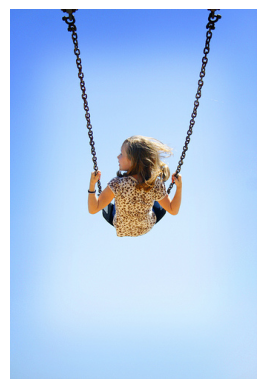


--- AI GENERATED CAPTION ---
🤖 Model says: a a little little girl girl wearing wearing a a blue blue hat hat swinging ride on on a a <UNK> swing swing

--- ORIGINAL HUMAN CAPTIONS ---
👤 Human 1: a girl rides on a swing
👤 Human 2: a girl swings high in the air
👤 Human 3: a little girl swings high in artistic photograph
👤 Human 4: a young girl rides a swing high into the blue sky
👤 Human 5: the blond haired girl wearing the flowered dress is swinging on a swing towards the blue sky


In [28]:
import random
import os
import matplotlib.pyplot as plt
from PIL import Image

# ==========================================
# 1. THE INFERENCE ENGINE
# ==========================================
def generate_caption(image_name, encoder, decoder, word_to_id, id_to_word, max_length=40):
    # 1. Grab the 2048-number image vector from our dictionary
    # We add unsqueeze(0) to simulate a "Batch Size of 1"
    image_feature = features[image_name].unsqueeze(0).to(device) 
    
    # 2. Get the IDs for our special tokens
    start_id = word_to_id.get('<start>') 
    end_id = word_to_id.get('<end>')
    
    # Start our sentence with just the <start> token
    predicted_ids = [start_id]
    
    # Turn on Evaluation mode (turns off dropout)
    encoder.eval()
    decoder.eval()
    
    with torch.no_grad(): # Turn off gradient memory
        # Squeeze the image down to 256 features
        encoded_image = encoder(image_feature)
        
        for _ in range(max_length):
            # Convert our growing list of words into a PyTorch tensor
            caption_tensor = torch.tensor([predicted_ids]).to(device)
            
            # Pass the image and the words we have so far into the brain
            outputs = decoder(encoded_image, caption_tensor) 
            
            # outputs shape is [1, current_sentence_length, 2572]
            # We only care about the very last word it guessed (index -1)
            last_word_scores = outputs[0, -1, :]
            
            # Find the vocabulary ID with the highest probability
            predicted_id = last_word_scores.argmax().item()
            
            # Add the guess to our list so we can feed it back in on the next loop
            predicted_ids.append(predicted_id)
            
            # If the model guessed <end>, the sentence is finished!
            if predicted_id == end_id:
                break
                
    # 3. Translate the math IDs back into English words
    generated_words = []
    for word_id in predicted_ids:
        word = id_to_word.get(word_id, '<UNK>')
        # Clean up the output so it reads like a normal human sentence
        if word not in ['<start>', '<end>', '<PAD>']:
            generated_words.append(word)
            
    return " ".join(generated_words)

# ==========================================
# 2. TEST IT ON A RANDOM IMAGE
# ==========================================
# Grab a random image from the TEST split (so the model has never seen it!)
test_image_name = random.choice(test_names)

# Ask the AI to write a caption
predicted_sentence = generate_caption(test_image_name, encoder, decoder, word_to_id, id_to_word)

# Get the original human captions to compare
human_captions = test_captions[test_image_name]

# --- DISPLAY THE RESULTS ---
# IMPORTANT: Change this path to match wherever your Flickr8k images are unzipped in Colab!
IMAGE_DIR = '/kaggle/input/datasets/adityajn105/flickr8k/Images'
img_path = os.path.join(IMAGE_DIR, test_image_name)

img = Image.open(img_path)
plt.imshow(img)
plt.axis('off')
plt.show()

print(f"\n--- AI GENERATED CAPTION ---")
print(f"🤖 Model says: {predicted_sentence}")

print(f"\n--- ORIGINAL HUMAN CAPTIONS ---")
for i, cap in enumerate(human_captions):
    # Clean up the human captions for nice printing
    clean_cap = cap.replace('<start> ', '').replace(' <end>', '')
    print(f"👤 Human {i+1}: {clean_cap}")